In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

In [2]:
df=pd.read_csv(r"C:\Users\SATWIK\OneDrive\Desktop\MachineLearning\Email Spam Detection\spam mail.csv")
df

,Category,Masseges
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


<Axes: xlabel='Category'>

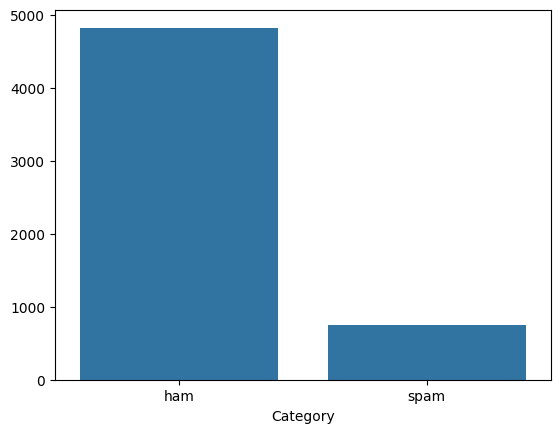

In [3]:
dist = df['Category'].value_counts()
sns.barplot( x=dist.index, y=dist.values)

([<matplotlib.patches.Wedge at 0x22965353310>,
 [Text(-1.0038715425384215, 0.4497131597824666, 'ham'),
  Text(1.0038714746336121, -0.44971331136284726, 'spam')],
 [Text(-0.547566295930048, 0.24529808715407267, '86.6%'),
  Text(0.5475662588910611, -0.24529816983428027, '13.4%')])

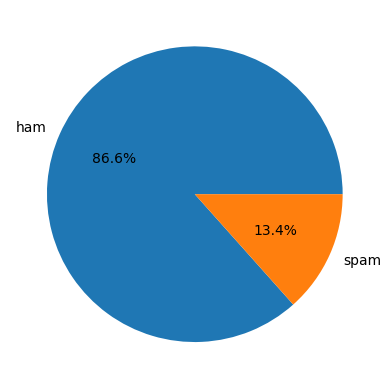

In [4]:
plt.pie(
    dist.values,
    labels=dist.index,
    autopct='%1.1f%%'
)

In [5]:
df['Category'] = df['Category'].map({'ham':0,'spam':1})
df

,Category,Masseges
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [6]:
x = df['Masseges']
y = df['Category']

In [7]:
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42
)

In [8]:
tfidf = TfidfVectorizer(
    lowercase=True,
    stop_words='english',
    max_features=5000
)

x_train_tfid = tfidf.fit_transform(x_train)
x_test_tfid = tfidf.transform(x_test)

In [9]:
y_train.head()

1978    0
3989    1
3935    0
4078    0
4086    1
Name: Category, dtype: int64

In [10]:
print(y.isna().sum())

0


In [11]:
model = LogisticRegression()
model.fit(x_train_tfid, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [12]:
y_pred = model.predict(x_test_tfid)
y_pred

array([0, 0, 0, ..., 0, 0, 0])

In [14]:
accuracy = accuracy_score(y_test,y_pred)
accuracy

0.9587443946188341

In [15]:
prec = precision_score(y_test,y_pred)
prec

0.9727272727272728

In [16]:
recall = recall_score(y_test,y_pred)
recall

0.7133333333333334

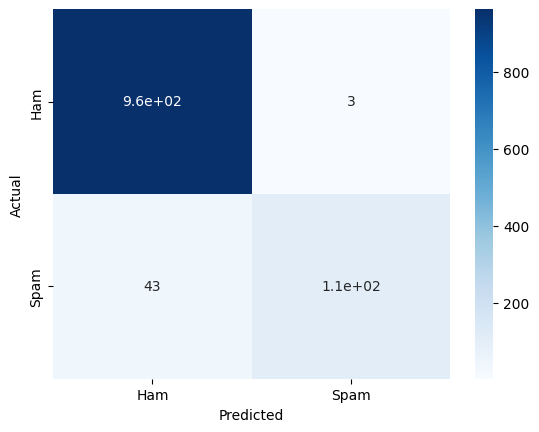

In [19]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(
    cm,
    annot=True,
    cmap='Blues',
    xticklabels=['Ham', 'Spam'],
    yticklabels=['Ham', 'Spam']
)

plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()